**Goal:** run a real first-look EDA on a real dataset -- summary statistics, missing
values, and the three one-variable plots -- and practice *reading* every output. Pairs
with the concept note
[One Variable at a Time: Distributions & Summary Statistics](l07_concept_univariate_eda.qmd).

> This page is the read-only view. To run the lab, open the notebook
> (`l07_lab_univariate_eda.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Prerequisites & Setup

Run this first. The dataset is **Palmer Penguins**: 344 penguins measured at Palmer
Station, Antarctica (Gorman, Williams & Fraser 2014, *PLoS ONE*; CC0 public domain).
It is bundled with the course as `data/penguins.csv`; the cell falls back to the
canonical seaborn-data mirror when the notebook runs standalone (for example, a fresh
Colab session). No random numbers in this lab, so there is nothing to seed -- everyone
sees identical results.

In [1]:
# Setup: run this cell first (required for Colab -- it resets on open)
%pip install -q pandas matplotlib seaborn

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Palmer Penguins -- Gorman, Williams & Fraser (2014), PLoS ONE; CC0 public domain
LOCAL = "data/penguins.csv"
URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
penguins = pd.read_csv(LOCAL if os.path.exists(LOCAL) else URL)
print(penguins.shape)
penguins.head(3)

Note: you may need to restart the kernel to use updated packages.


(344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE


<details><summary>Expected Output</summary>

~~~text
(344, 7)
~~~
*(...followed by the first three rows: three Adelie penguins from Torgersen island, with
their bill, flipper, and body-mass measurements.)*
</details>

## Step 1: First Look -- Structure, Quality, and the Headline Numbers

Every EDA starts with the same three questions: *what is here* (structure), *what is
broken* (quality), and *what are the headline numbers*. Three pandas calls answer them.

In [2]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


<details><summary>Expected Output</summary>

~~~text
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   species            344 non-null    object
 1   island             344 non-null    object
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
~~~
</details>

**Read it:** 344 rows; four numeric measurement columns and three text (categorical)
columns. The Non-Null counts already whisper the quality story: the measurements have
342 of 344, and `sex` only 333.

In [3]:
print(penguins.isna().sum())
print()
print(penguins["species"].value_counts())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


<details><summary>Expected Output</summary>

~~~text
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
~~~
</details>

**Read it:** two penguins are missing all four measurements, and eleven are missing
`sex`. Counting the damage is the first act of EDA -- pandas will silently skip NaNs in
every statistic below, so these numbers tell you what fraction of the column each
statistic actually describes. The species counts are imbalanced: Chinstrap (68) has
less than half the rows of Adelie (152) -- worth remembering whenever we compare groups.

In [4]:
penguins.describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.22,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00


<details><summary>Expected Output</summary>

~~~text
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          342.00         342.00             342.00       342.00
mean            43.92          17.15             200.92      4201.75
std              5.46           1.97              14.06       801.95
min             32.10          13.10             172.00      2700.00
25%             39.22          15.60             190.00      3550.00
50%             44.45          17.30             197.00      4050.00
75%             48.50          18.70             213.00      4750.00
max             59.60          21.50             231.00      6300.00
~~~
</details>

**Read it:** one table, eight numbers per variable -- count, mean, std, and the
five-number summary. Body mass runs from 2.7 kg to 6.3 kg. Now the concept note's
headline check, mean versus median:

In [5]:
bm = penguins["body_mass_g"]
print(f"mean  : {bm.mean():7.1f} g")
print(f"median: {bm.median():7.1f} g")
print(f"std   : {bm.std():7.1f} g")

mean  :  4201.8 g
median:  4050.0 g
std   :   802.0 g


<details><summary>Expected Output</summary>

~~~text
mean  :  4201.8 g
median:  4050.0 g
std   :   802.0 g
~~~
*(Mean about 150 g above the median: a mild right skew. Some heavier penguins are
pulling the mean up -- the plots in Step 2 will show us who.)*
</details>

## Step 2: Histogram and KDE -- the Shape of Body Mass

Start naive: pandas will happily draw a histogram with its default of 10 bins.

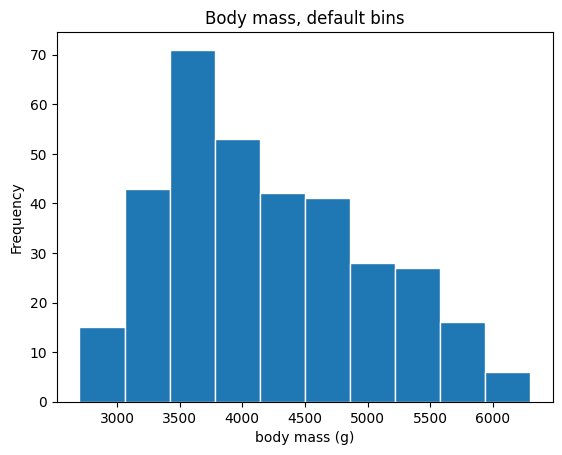

In [6]:
penguins["body_mass_g"].plot.hist(edgecolor="white", title="Body mass, default bins")
plt.xlabel("body mass (g)")
plt.show()

**Read it:** right-skewed, as the mean-median gap predicted -- and there is a hint of a
second bump around 5000 g, but at 10 bins it is hard to tell structure from accident.

The bin count is the histogram's one real decision, so never settle for the default.
**Uncomment and complete** the better version: 30 bins, with the smooth KDE curve
overlaid to double-check whatever shape the bins suggest.

In [7]:
# Uncomment and fill the two ____ blanks, then run:
# sns.histplot(penguins["body_mass_g"], bins=____, kde=____)   # 30 bins; kde wants True/False
# plt.title("Body mass, 30 bins + KDE")
# plt.show()

<details><summary>Expected Output</summary>

*(A histogram with two distinct peaks -- a tall one near 3500 g and a second one near
5000 g -- with the KDE curve tracing the same two humps. At 30 bins, with the KDE
agreeing, the second bump is clearly real structure, not a binning artifact: the
distribution is **bimodal**. A second peak in a measurement variable usually means the
data is a mixture of groups. Step 3 and Exercise 1 will unmask the groups.)*
</details>

## Step 3: Box Plot and the 1.5 x IQR Rule

Third view of the same variable: the five-number summary, drawn.

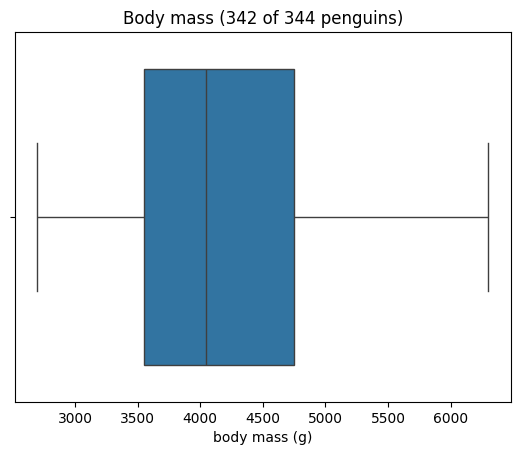

In [8]:
sns.boxplot(x=penguins["body_mass_g"])
plt.title("Body mass (342 of 344 penguins)")
plt.xlabel("body mass (g)")
plt.show()

**Read it:** the median line sits left of the box center and the right whisker is
longer -- skew, again, third way of seeing it. (The title says 342: seaborn silently
dropped the two NaNs Step 1 counted -- which is exactly why we counted them first.) Notice there are **no dots** beyond the
whiskers. Verify that by hand: **uncomment and complete** the two fence formulas
(concept note: fences sit 1.5 IQRs beyond the quartiles).

In [9]:
q1 = penguins["body_mass_g"].quantile(0.25)
q3 = penguins["body_mass_g"].quantile(0.75)
iqr = q3 - q1

# Uncomment and fill the two ____ blanks (how far beyond the quartiles do the fences sit?):
# lower = q1 - ____ * iqr
# upper = q3 + ____ * iqr
# flagged = penguins[(penguins["body_mass_g"] < lower) | (penguins["body_mass_g"] > upper)]
# print(f"fences: {lower:.1f} g .. {upper:.1f} g   flagged: {len(flagged)}")

<details><summary>Expected Output</summary>

~~~text
fences: 1750.0 g .. 6550.0 g   flagged: 0
~~~
*(The fences sit far below the minimum of 2700 g and above the maximum of 6300 g, so
nothing is flagged -- which matches the dot-free box plot.)*
</details>

Zero flagged points. Is the dataset outlier-free, then? Careful -- Step 2 showed this
variable is a **mixture** of species, and mixtures inflate the IQR, which pushes the
fences far out. Watch what happens when we apply the same rule *within one species*:

In [10]:
chinstrap = penguins[penguins["species"] == "Chinstrap"]["body_mass_g"]
q1c, q3c = chinstrap.quantile(0.25), chinstrap.quantile(0.75)
iqr_c = q3c - q1c
lower_c, upper_c = q1c - 1.5 * iqr_c, q3c + 1.5 * iqr_c
flagged_c = chinstrap[(chinstrap < lower_c) | (chinstrap > upper_c)]
print(f"Chinstrap fences: {lower_c:.1f} g .. {upper_c:.1f} g   flagged: {len(flagged_c)}")
print(flagged_c)

Chinstrap fences: 2793.8 g .. 4643.8 g   flagged: 2
189    4800.0
190    2700.0
Name: body_mass_g, dtype: float64


<details><summary>Expected Output</summary>

~~~text
Chinstrap fences: 2793.8 g .. 4643.8 g   flagged: 2
189    4800.0
190    2700.0
Name: body_mass_g, dtype: float64
~~~
*(Two Chinstraps -- one unusually heavy at 4800 g, one unusually light at 2700 g -- are
flagged the moment the comparison group is honest. The 1.5 x IQR rule is only as good
as the population you apply it to.)*
</details>

## Your Turn

### Exercise 1 -- Whose Second Bump Is It?

Step 2 found two peaks in body mass. Investigate with a different variable: plot a
**histogram of `flipper_length_mm` with 30 bins**, describe its shape, then compute the
**mean flipper length per species** (`groupby`) to identify which species causes the
separate peak.

**Hint:** `sns.histplot` for the picture;
`penguins.groupby("species")["flipper_length_mm"].mean().round(1)` is the unmasking
pattern -- print it.

In [11]:
# TODO: your code here (one histogram, one groupby)

<details><summary>Expected Output</summary>

~~~text
species
Adelie       190.0
Chinstrap    195.8
Gentoo       217.2
Name: flipper_length_mm, dtype: float64
~~~
*(The histogram is clearly bimodal: a tall cluster near 190 mm and a separate one near
217 mm. The groupby unmasks the mixture -- Adelie and Chinstrap overlap around 190-196 mm
and form the first peak; Gentoo, about 20 mm longer, is the second. One "variable" was
really three species stacked together.)*
</details>

### Exercise 2 -- Which Number Do You Report?

**Task:** a dataset of hospital stay lengths has mean 6.8 days and median 3.0 days.
In two or three sentences: what does the gap tell you about the distribution's shape,
which number describes the *typical* stay, and when would the mean still be the right
number to use?

<details><summary>One acceptable answer</summary>

Mean far above median means strong right skew: most stays are short, a few very long
stays drag the mean up. The typical stay is the median, 3 days. The mean is still the
right number for *capacity math* -- total bed-days expected from N admissions is N times
the mean, not the median.
</details>

### Exercise 3 -- Drop Them or Keep Them?

**Task:** Step 3 flagged two Chinstrap penguins, at 4800 g and 2700 g. In two or three
sentences, decide what to do with them and justify it. (Hint: what are the *possible
explanations* for a flagged point, and which apply to a hand-weighed penguin?)

<details><summary>One acceptable answer</summary>

Keep them. Both values are biologically plausible (well within the range other species
reach), so they are most likely genuinely large and small individuals, not recording
errors. The 1.5 x IQR rule flags candidates for inspection, not deletion -- dropping
real animals would bias every Chinstrap statistic. If a value were impossible (say,
270 g), the right fix would be to investigate the record, not to silently delete it.
</details>

## Summary

- The first-look ritual: `shape` / `info()` for structure, `isna().sum()` for damage,
  `describe()` for headline numbers -- *before* any plot or model.
- Mean 4201.8 g vs median 4050.0 g flagged the right skew; the histogram revealed the
  cause was **bimodality** (a species mixture), which no summary statistic showed.
- The 1.5 x IQR rule flagged 0 points on the full data but 2 within Chinstrap: the rule
  is relative to the group you feed it, and a flag means *inspect*, never *delete*.
- Three plots, one variable: histogram (shape), KDE (smooth check on the bins), box
  plot (five-number summary + flags). For categorical columns: `value_counts()` and a
  bar chart.